# Seismic Oceanography: Inversion via Genetic Algorithms

This notebook orchestrates the inversion workflow to estimate the physical properties of the water column (specifically the P-wave velocity, $V_p$) by optimizing EOF (Empirical Orthogonal Function) coefficients.

To ensure robust implementation, a smoothed velocity model is utilized here for algorithm validation (synthetic testing). The optimization is handled via the DEAP framework to perform a global search and minimize the phase misfit between the synthetic and observed seismic traces.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import multiprocessing
from deap import algorithms, tools
import xarray as xr
import torch
import matplotlib.pyplot as plt


project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Internal modules
from ocean_inversion.config import (MODEL_VP0,MODEL_RHO0,MODEL_EOFS,MODEL_COEF_HIST,MARGEM_COEF,
                                    DZ,DT,NT,F_PEAK,Z_MAX,
                                    SEED, N_INV, NUM_PROCESS, POPULATION, CXPB, MUTPB, NGEN, TOURNSIZE,HOF_NUM,ETA_GENE)


from ocean_inversion.evolutionary_algorithm import (
    init_worker,
    configure_deap_ocean,
    statistics_save
)

from ocean_inversion.modeling import (
    mute_direct_arrival,normalize_data,
    calculate_synthetic_trace,ricker_wavelet,
    geometric_spreading_correction,bandpass_filter,
    crop_seismogram_by_depth,add_white_noise,apply_edge_taper
)



[ocean_inversion.config] Reading configuration file: /home/sysop/diogogit/NFH_inversion_seismic_oceanography/config_file.cnf


/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


## 1. Data Loading and Setup

In this section, we load the required datasets: the baseline velocity model, the EOF basis vectors, the density model ($\rho$), and the observed seismic traces. We also define the seismic configuration parameters such as peak frequency and sampling rate to generate the source wavelet.

In [2]:
# Load EOF basis and base models (example using xarray and numpy)
vp_base = np.load(MODEL_VP0)

rho_model = np.load(MODEL_RHO0)

eof_basis=np.load(MODEL_EOFS)

coef_hist=np.load(MODEL_COEF_HIST)

low = coef_hist.min(axis=1)
high = coef_hist.max(axis=1)

faixa = high - low
coef_mins = low - MARGEM_COEF * faixa
coef_maxs = high + MARGEM_COEF * faixa


## 1.1 Observed data

In [3]:
device = torch.device("cpu")

ds = xr.open_zarr("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/dados_observados/ocean_data_synthetic.zarr")

subset = ds.amplitude.isel(shot=slice(0, 1),receiver=slice(0, 1)).load()

observed_data = torch.as_tensor(subset.values,dtype=torch.float32,device=device).numpy().squeeze()


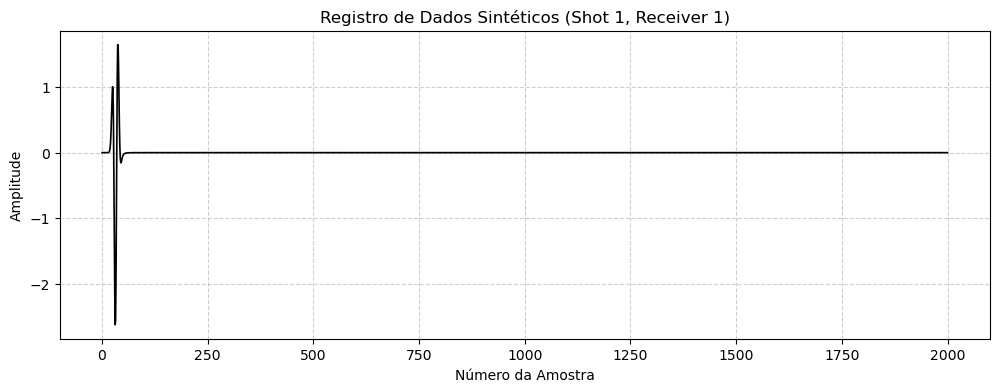

In [4]:
import matplotlib.pyplot as plt

# Cria a figura com um tamanho adequado (largura, altura)
plt.figure(figsize=(12, 4))

# Plota os dados
plt.plot(observed_data, color='black', linewidth=1.2)

# Adiciona títulos e rótulos aos eixos
plt.title("Registro de Dados Sintéticos (Shot 1, Receiver 1)")
plt.xlabel("Número da Amostra")
plt.ylabel("Amplitude")

# Adiciona um grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico na tela
plt.show()

## 1.2 Removing direct wave from Observed data

In [5]:
s_obs = geometric_spreading_correction(observed_data, dt=DT, mode="cylindrical")

s_obs = mute_direct_arrival(
    trace=s_obs,
    offset=25,
    dt=DT,
    freq=F_PEAK,
    peak_time=1.5/F_PEAK
)
#s_obs = add_white_noise(s_obs, snr_db=15)

# Definir um nível de SNR, por exemplo, 10 dB (ruído moderado)
s_obs = bandpass_filter(s_obs, dt=DT, f_peak=F_PEAK) 



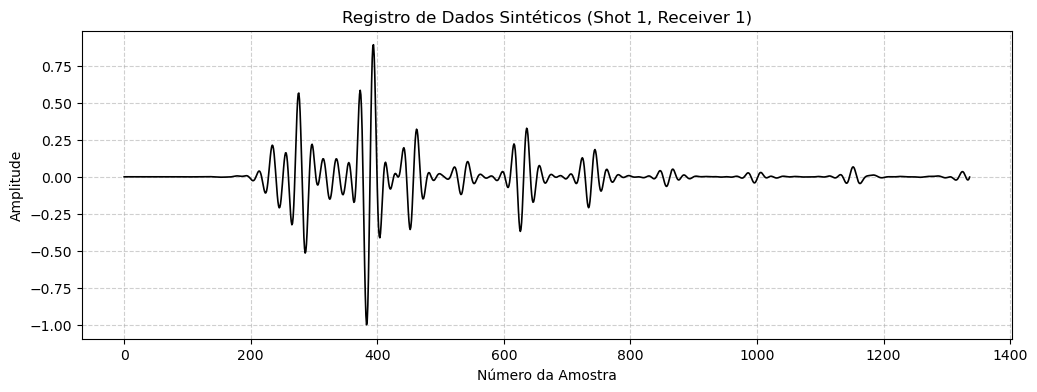

In [6]:

s_obs = crop_seismogram_by_depth(seismogram=s_obs, base_model=vp_base, dz=DZ, dt=DT, z_max=Z_MAX)

s_norm = normalize_data(s_obs,method="trace_max")

# Cria a figura com um tamanho adequado (largura, altura)
plt.figure(figsize=(12, 4))

# Plota os dados
plt.plot(s_norm, color='black', linewidth=1.2)

# Adiciona títulos e rótulos aos eixos
plt.title("Registro de Dados Sintéticos (Shot 1, Receiver 1)")
plt.xlabel("Número da Amostra")
plt.ylabel("Amplitude")

# Adiciona um grid para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Mostra o gráfico na tela
plt.show()

## 2. Genetic Algorithm Configuration

Here we configure the Distributed Evolutionary Algorithms in Python (DEAP) framework. We set the boundaries for the EOF coefficients and map the parallel processing pool. The fitness evaluation relies on the phase misfit objective function imported from our modules.

In [7]:
# ----------
# GLOBAL RNG

main_rng = np.random.default_rng(SEED)

population_first = []

with multiprocessing.Pool(processes=NUM_PROCESS, initializer=init_worker, initargs=(SEED,)) as pool:

    # --------------
    # Starting DEAP:
                        
    # Parameters (Space search) and configuration:
    toolbox = configure_deap_ocean(vp_base, eof_basis, coef_mins, coef_maxs, s_norm, F_PEAK, DT, DZ, NT,Z_MAX, rho_model, ETA_GENE, MUTPB, TOURNSIZE, pool.map, main_rng)

    # Starting population:
    population = toolbox.population(n=POPULATION)
    population_first += population
    # Starting statistical measurement:
    estatistica = tools.Statistics(statistics_save)
    estatistica.register('mean', np.mean)
    estatistica.register('min', np.min)
    estatistica.register('max', np.max)

    # Starting best solution estimation:
    hof = tools.HallOfFame(HOF_NUM)
                    
    # Starting the algorithm
    result, log = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,stats=estatistica, halloffame=hof, verbose=True)


gen	nevals	mean  	min    	max   
0  	1000  	2.9384	1.36023	6.7607
1  	777   	2.53905	1.19667	7.22324
2  	815   	2.39488	1.19667	6.89849
3  	782   	2.26676	1.19667	6.83406
4  	793   	2.2631 	1.22957	6.05975
5  	798   	2.19551	1.245  	6.23712
6  	800   	2.10603	1.28336	5.87729
7  	809   	2.05928	1.22798	5.18421
8  	797   	1.96132	1.18602	6.42608
9  	782   	1.90649	1.18602	5.69641
10 	800   	1.84801	1.16241	5.32641
11 	761   	1.77774	1.15708	5.79092
12 	779   	1.68349	1.14327	5.39056
13 	818   	1.6257 	1.14327	4.51929
14 	826   	1.57797	1.17149	4.70547
15 	782   	1.53881	1.17763	6.07621
16 	809   	1.48944	1.13097	3.33495
17 	793   	1.45368	1.13097	5.49963
18 	805   	1.44895	1.13625	3.15857
19 	755   	1.42257	1.13637	3.58565
20 	780   	1.3998 	1.12658	3.28342
21 	776   	1.39438	1.12411	3.16787
22 	759   	1.36852	1.12529	4.00374
23 	810   	1.36758	1.1058 	3.79943
24 	786   	1.34869	1.1058 	3.18249
25 	778   	1.32803	1.1058 	3.01451
26 	796   	1.32539	1.11749	2.83884
27 	808   	1.31332	1.114

In [8]:

v_numpy = np.fromfile("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/modelo_inicial/sound_speed.bin", dtype=np.float32).reshape(2501, 5564)

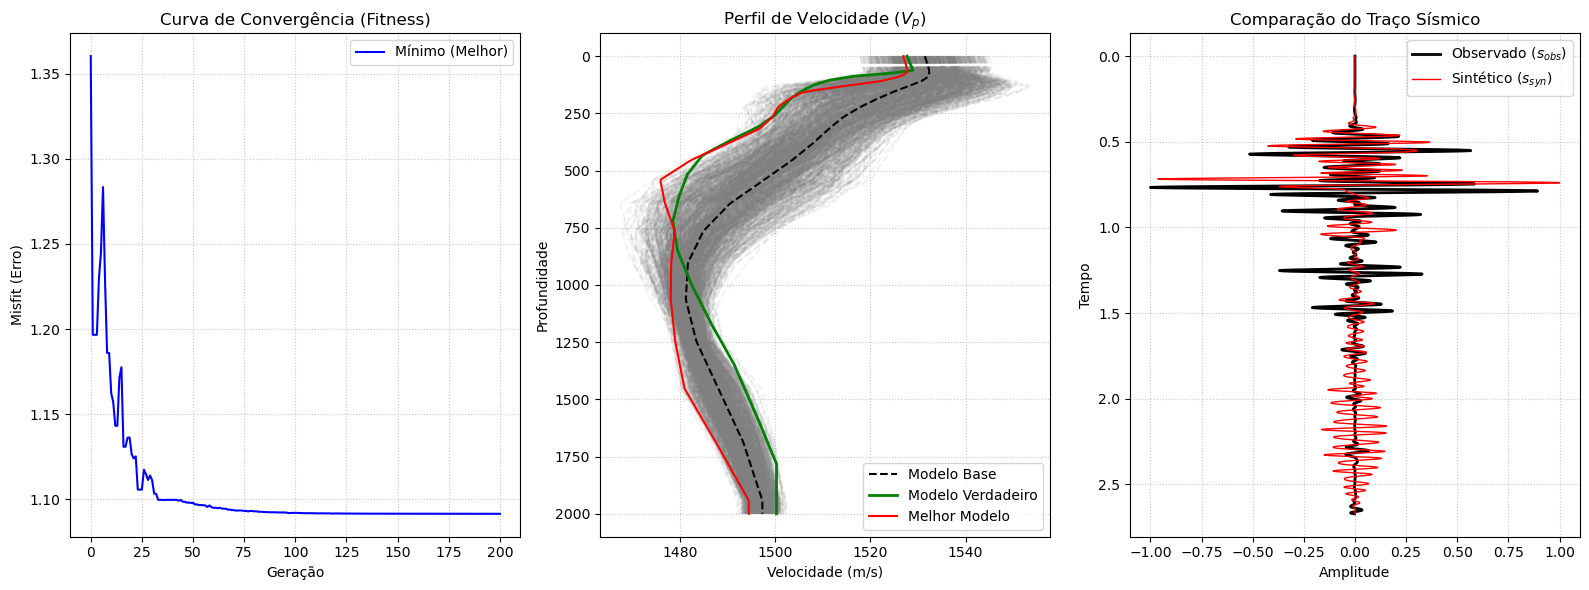

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. EXTRAÇÃO DOS RESULTADOS DO DEAP
# ==========================================

# Extraindo estatísticas do logbook
gen = log.select("gen")
fit_mins = log.select("min")    # Melhor fitness por geração
fit_means = log.select("mean")  # Fitness médio por geração
fit_maxs = log.select("max")  # Fitness médio por geração

# Pegando o melhor indivíduo absoluto da evolução
best_ind = result[0]

# ==========================================
# 2. RECONSTRUÇÃO DO MELHOR MODELO
# ==========================================
# Aqui você precisa usar a mesma lógica que usa dentro da função objetivo 
# para transformar os "genes" (best_ind) de volta nos perfis de Vp e Rho.
# Exemplo genérico (ajuste para a sua função real de EOF):

# 1. Pegar os genes do melhor indivíduo (coeficientes dos EOFs)
best_ind = np.array(hof[0])

# 2. Reconstruir o perfil de velocidade (Vp)
# O modelo final é o perfil base somado à perturbação calculada pelos EOFs
vp_best = vp_base + np.dot(eof_basis, best_ind)

# ==========================================
# 3. PLOTAGEM
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

# --- PLOT 1: Curva de Convergência ---
axs[0].plot(gen, fit_mins, 'b-', label='Mínimo (Melhor)')
#axs[0].plot(gen, fit_means, 'g--', label='Média da População')
#axs[0].plot(gen, fit_maxs, 'r--', label='Média da População')
axs[0].set_title("Curva de Convergência (Fitness)")
axs[0].set_xlabel("Geração")
axs[0].set_ylabel("Misfit (Erro)")
axs[0].grid(True, linestyle=':', alpha=0.7)
axs[0].legend()

# --- PLOT 2: Perfis de Velocidade (Vp) ---
# Criando um eixo de profundidade genérico (substitua pelo seu vetor real, ex: z_depth)
vp_true = v_numpy.T[0]

z_base = np.linspace(0, Z_MAX, len(vp_base))
z_true = np.linspace(0, Z_MAX, len(vp_true))
vp_best = vp_base + np.dot(eof_basis,best_ind)
for pop in population_first:
    axs[1].plot(vp_base + np.dot(eof_basis,pop), z_base, c='gray',ls='--',alpha=0.1)
    
axs[1].plot(vp_base, z_base, 'k--', label='Modelo Base')
axs[1].plot(vp_true, z_true, 'g-', linewidth=2, label='Modelo Verdadeiro')

axs[1].plot(vp_best, z_base, 'r-', label='Melhor Modelo')
axs[1].invert_yaxis() # Profundidade aumenta para baixo
axs[1].set_title("Perfil de Velocidade ($V_p$)")
axs[1].set_xlabel("Velocidade (m/s)")
axs[1].set_ylabel("Profundidade")
axs[1].grid(True, linestyle=':', alpha=0.7)
axs[1].legend()

# --- PLOT 3: Traços Sísmicos ---

# 3. Definir o perfil de densidade (Rho)
# Pela sua função de configuração, o rho_model parece ser constante para todos os testes
rho_best = rho_model 

# 4. Estimar o traço sintético

wavelet = ricker_wavelet(F_PEAK, DT)
s_syn_best = calculate_synthetic_trace(vp_profile=vp_best, 
    rho_profile=rho_best, 
    wavelet=wavelet,
    dz=DZ,
    dt=DT,
    nt=NT)

s_syn_best_mute = mute_direct_arrival(trace=s_syn_best,offset=25,dt=DT,freq=F_PEAK,peak_time=1.5/F_PEAK)

s_syn_best_mute = bandpass_filter(s_syn_best_mute, dt=DT, f_peak=F_PEAK) 

s_syn_best_mute = crop_seismogram_by_depth(seismogram=s_syn_best_mute, base_model=vp_base, dz=DZ, dt=DT, z_max=Z_MAX)
s_syn_best_mute = apply_edge_taper(s_syn_best_mute)

s_syn_best_norm = normalize_data(s_syn_best_mute,method="trace_max")

t_obs = np.arange(len(s_norm))*DT
t_syn = np.arange(len(s_syn_best_norm))*DT

axs[2].plot(s_norm, t_obs, 'k-', linewidth=2, label='Observado ($s_{obs}$)')
axs[2].plot(s_syn_best_norm, t_syn, 'r-', linewidth=1, label='Sintético ($s_{syn}$)')
axs[2].invert_yaxis() # Tempo aumenta para baixo (padrão em sísmica)
axs[2].set_title("Comparação do Traço Sísmico")
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("Tempo")
axs[2].grid(True, linestyle=':', alpha=0.7)
axs[2].legend()

plt.tight_layout()
plt.show()

## 3. Uncertainty Analysis of the Hall of Fame

Once the optimization loop converges, we extract the best individuals from the Hall of Fame. We apply a Bootstrap resampling method to estimate the standard deviation and confidence intervals of our inverted model, ensuring the robustness of the structural reconstruction.

## 1.2 Removing direct wave from Observed data

In [10]:
# Prepare a DataFrame structure from the Hall of Fame to feed into the bootstrap function
hof_vp_profiles = [vp_base + np.dot(eof_basis, ind) for ind in hof]

# Example DataFrame creation (adapt the keys 'survey', 'vp', 'depth' to match your data structure)
# df_hof = pd.DataFrame({
#     'survey': ['Survey_OS2'] * len(hof),
#     'vp': hof_vp_profiles,
#     'depth': [np.arange(len(vp_base))] * len(hof)
# })

# Run Bootstrap analysis on the results
# bootstrap_results = bootstrap_hof_uncertainty(
#     df_input=df_hof, 
#     rng=main_rng, 
#     n_iterations=500, 
#     ci_percentiles=[2.5, 97.5]
# )

# print(f"Mean Vp Profile: {bootstrap_results['mean_v']}")